# Prepare data

## Data preparation - step 1


In [ ]:
from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.sql.functions import col
from pyspark.sql.functions import col, isnan
import seaborn as sns
import matplotlib.pyplot as plt
import setuptools
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, Imputer
from pyspark.ml.pipeline import Pipeline
from pyspark.ml.regression import LinearRegression
from pyspark.ml.regression import RandomForestRegressor as RF
from pyspark.sql.window import Window
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
import pandas as pd
import folium
import requests
import json

In the following, knowing that there is no header in the files and ";" is the seperator, we specified those options to import and merge the prices files from 2022 to 2024.

In [ ]:
spark = (SparkSession.builder
         .appName("Prix")
         .config("spark.driver.memory", "12g")
         .config("spark.executor.memory", "12g")
         .config("spark.executor.cores", "12")
         .getOrCreate())

files_path = "../Data/1-raw/Prix*.csv.gz"

df_prices = (spark.read
    #.option("header", True)
    .option("inferSchema", True) 
    .option("sep", ";")              
    .csv(files_path)                 
)

df_prices.head(5)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/13 18:38:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


[Row(_c0=1000001, _c1=1000, _c2='R', _c3=4620100.0, _c4=519800.0, _c5=datetime.datetime(2023, 1, 2, 7, 53, 26), _c6=1, _c7='Gazole', _c8=1.867),
 Row(_c0=1000001, _c1=1000, _c2='R', _c3=4620100.0, _c4=519800.0, _c5=datetime.datetime(2023, 1, 5, 9, 33, 37), _c6=1, _c7='Gazole', _c8=1.877),
 Row(_c0=1000001, _c1=1000, _c2='R', _c3=4620100.0, _c4=519800.0, _c5=datetime.datetime(2023, 1, 9, 14, 51, 49), _c6=1, _c7='Gazole', _c8=1.875),
 Row(_c0=1000001, _c1=1000, _c2='R', _c3=4620100.0, _c4=519800.0, _c5=datetime.datetime(2023, 1, 11, 9, 23, 54), _c6=1, _c7='Gazole', _c8=1.859),
 Row(_c0=1000001, _c1=1000, _c2='R', _c3=4620100.0, _c4=519800.0, _c5=datetime.datetime(2023, 1, 13, 9, 7, 40), _c6=1, _c7='Gazole', _c8=1.862)]

In the read.me, we saw the name of the columns and their descriptions. We just included them in order to rename our columns.

In [3]:
cols = [
    "id_pdv", "cp", "pop",
    "latitude", "longitude",
    "date",
    "id_carburant", "nom_carburant",
    "prix"
]

df_prices = df_prices.toDF(*cols)
df_prices.show(5)
df_prices.printSchema()

+-------+----+---+---------+---------+-------------------+------------+-------------+-----+
| id_pdv|  cp|pop| latitude|longitude|               date|id_carburant|nom_carburant| prix|
+-------+----+---+---------+---------+-------------------+------------+-------------+-----+
|1000001|1000|  R|4620100.0| 519800.0|2023-01-02 07:53:26|           1|       Gazole|1.867|
|1000001|1000|  R|4620100.0| 519800.0|2023-01-05 09:33:37|           1|       Gazole|1.877|
|1000001|1000|  R|4620100.0| 519800.0|2023-01-09 14:51:49|           1|       Gazole|1.875|
|1000001|1000|  R|4620100.0| 519800.0|2023-01-11 09:23:54|           1|       Gazole|1.859|
|1000001|1000|  R|4620100.0| 519800.0|2023-01-13 09:07:40|           1|       Gazole|1.862|
+-------+----+---+---------+---------+-------------------+------------+-------------+-----+
only showing top 5 rows

root
 |-- id_pdv: integer (nullable = true)
 |-- cp: integer (nullable = true)
 |-- pop: string (nullable = true)
 |-- latitude: double (nullable =

Knowing the previous format of the files, we use the withColumn methods to extract the year, the month and the week of the year.

In [4]:
df_prices = (df_prices
    .withColumn("year",  F.year("date"))
    .withColumn("month", F.month("date"))
    .withColumn("week_of_year", F.weekofyear("date"))
)

df_prices.select("date","year","month","week_of_year").show(5)

+-------------------+----+-----+------------+
|               date|year|month|week_of_year|
+-------------------+----+-----+------------+
|2023-01-02 07:53:26|2023|    1|           1|
|2023-01-05 09:33:37|2023|    1|           1|
|2023-01-09 14:51:49|2023|    1|           2|
|2023-01-11 09:23:54|2023|    1|           2|
|2023-01-13 09:07:40|2023|    1|           2|
+-------------------+----+-----+------------+
only showing top 5 rows



In [5]:
# We divide the columns longitude and latitude by 10^5
# as it was making sense for the first one and keeping five zeros is common in order to get a 1-meter precision 
df_prices = (df_prices 
.withColumn("latitude", (F.col("latitude") / 100000)) 
.withColumn("longitude", (F.col("longitude") / 100000))
)

df_prices.select("latitude", "longitude").show(5)

+--------+---------+
|latitude|longitude|
+--------+---------+
|  46.201|    5.198|
|  46.201|    5.198|
|  46.201|    5.198|
|  46.201|    5.198|
|  46.201|    5.198|
+--------+---------+
only showing top 5 rows



In [6]:
# We try to identify all the rows with missing values
# As they are a few and they correspond to a small proportion, we will drop them all
condition = None
for c in df_prices.columns:
    if condition is None:
        condition = col(c).isNull() 
    else:
        condition = condition | col(c).isNull()

rows_with_na = df_prices.filter(condition)


count_rows_with_na = rows_with_na.count()
print(f"Numbers of rows with at least one NA: {count_rows_with_na}")
print(f"Proportion of rows with at least one NA: {count_rows_with_na / df_prices.count()}")


Numbers of rows with at least one NA: 12756


Proportion of rows with at least one NA: 0.000897372231563401


In [7]:
df_prices_filtered = df_prices.na.drop()

In [8]:
# In order to make the table available to spark SQL we use the the createOrReplaceTempView method
# We rename it prices_SQL
df_prices_filtered.createOrReplaceTempView('prices_SQL')
n_data = df_prices_filtered.count()

# We now will try to the distribution of each gas type in order to choose the two out of our interest
spark.sql(f""" 
SELECT nom_carburant, 
COUNT(*) * 1.0 / {n_data} AS freq 
FROM prices_SQL 
GROUP BY nom_carburant 
ORDER BY freq DESC 
"""
).show()


spark.sql(f"""
SELECT
  year,
  nom_carburant,
  COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY year) AS freq
FROM prices_SQL
GROUP BY year, nom_carburant
ORDER BY year, freq DESC
""").show()


+-------------+------------+
|nom_carburant|        freq|
+-------------+------------+
|       Gazole|0.2989266151|
|          E10|0.2506321433|
|         SP98|0.2412212689|
|          E85|0.0979138198|
|         SP95|0.0676675482|
|         GPLc|0.0436386048|
+-------------+------------+



+----+-------------+------------------+
|year|nom_carburant|              freq|
+----+-------------+------------------+
|2022|       Gazole|0.3071577117954053|
|2022|          E10|0.2471035455470010|
|2022|         SP98|0.2448219114743826|
|2022|          E85|0.0850825827424426|
|2022|         SP95|0.0749159165827607|
|2022|         GPLc|0.0409183318580078|
|2023|       Gazole|0.2985839418894967|
|2023|          E10|0.2512919696636149|
|2023|         SP98|0.2369624924706722|
|2023|          E85|0.1023582890292489|
|2023|         SP95|0.0671796467189213|
|2023|         GPLc|0.0436236602280460|
|2024|       Gazole|0.2904290313938861|
|2024|          E10|0.2537513517378210|
|2024|         SP98|0.2416986785938570|
|2024|          E85|0.1071685863650661|
|2024|         SP95|0.0603745346436153|
|2024|         GPLc|0.0465778172657545|
+----+-------------+------------------+



We notice by computing the proportion of each type of Gas by year and overall that the gas types SP95, GPLc and E85 are the least frequent with less than 10% each year so we decide to see their months frequencies in order to choose the two that we will delete.

In [9]:
spark.sql("""
SELECT
  year,
  month,
  nom_carburant,
  COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY year, month) AS freq
FROM prices_SQL
WHERE (nom_carburant IN ('SP95', 'GPLc', 'E85')) AND (year = 2023)
GROUP BY year, month, nom_carburant
ORDER BY year, month, freq DESC
""").show(50)


+----+-----+-------------+------------------+
|year|month|nom_carburant|              freq|
+----+-----+-------------+------------------+
|2023|    1|          E85|0.4587187621750988|
|2023|    1|         SP95|0.3409695552958201|
|2023|    1|         GPLc|0.2003116825290811|
|2023|    2|          E85|0.4859598015350440|
|2023|    2|         SP95|0.2940127964670045|
|2023|    2|         GPLc|0.2200274019979515|
|2023|    3|          E85|0.4796696081198837|
|2023|    3|         SP95|0.3196529167024632|
|2023|    3|         GPLc|0.2006774751776531|
|2023|    4|          E85|0.4934517113932187|
|2023|    4|         SP95|0.3101531951363222|
|2023|    4|         GPLc|0.1963950934704590|
|2023|    5|          E85|0.4860406572971879|
|2023|    5|         SP95|0.3085223463333797|
|2023|    5|         GPLc|0.2054369963694324|
|2023|    6|          E85|0.4956783454236765|
|2023|    6|         SP95|0.2934995112414467|
|2023|    6|         GPLc|0.2108221433348768|
|2023|    7|          E85|0.479579

After checking the frequencies of those last three gas types per month and per year, we see that E85 is the most frequent so will be most informative in order to predict a gas price.

In [10]:
df_clean = df_prices_filtered.filter(
    ~F.col("nom_carburant").isin(["GPLc", "SP95"])
)

df_clean.show(5)

+-------+----+---+--------+---------+-------------------+------------+-------------+-----+----+-----+------------+
| id_pdv|  cp|pop|latitude|longitude|               date|id_carburant|nom_carburant| prix|year|month|week_of_year|
+-------+----+---+--------+---------+-------------------+------------+-------------+-----+----+-----+------------+
|1000001|1000|  R|  46.201|    5.198|2023-01-02 07:53:26|           1|       Gazole|1.867|2023|    1|           1|
|1000001|1000|  R|  46.201|    5.198|2023-01-05 09:33:37|           1|       Gazole|1.877|2023|    1|           1|
|1000001|1000|  R|  46.201|    5.198|2023-01-09 14:51:49|           1|       Gazole|1.875|2023|    1|           2|
|1000001|1000|  R|  46.201|    5.198|2023-01-11 09:23:54|           1|       Gazole|1.859|2023|    1|           2|
|1000001|1000|  R|  46.201|    5.198|2023-01-13 09:07:40|           1|       Gazole|1.862|2023|    1|           2|
+-------+----+---+--------+---------+-------------------+------------+----------

## Data Preparation - step 2
We see in the following cell that for each station we have **one price per gas type per day**. For each gas type, we will average among every station for each day.

In [11]:
df_clean= (df_clean
    .withColumn("day",  F.to_date("date"))
)

df_clean.show(5)

df_clean.where(
    (F.col("day") == "2023-01-02") &
    (F.col("id_pdv") == 1000001)
).show()


+-------+----+---+--------+---------+-------------------+------------+-------------+-----+----+-----+------------+----------+
| id_pdv|  cp|pop|latitude|longitude|               date|id_carburant|nom_carburant| prix|year|month|week_of_year|       day|
+-------+----+---+--------+---------+-------------------+------------+-------------+-----+----+-----+------------+----------+
|1000001|1000|  R|  46.201|    5.198|2023-01-02 07:53:26|           1|       Gazole|1.867|2023|    1|           1|2023-01-02|
|1000001|1000|  R|  46.201|    5.198|2023-01-05 09:33:37|           1|       Gazole|1.877|2023|    1|           1|2023-01-05|
|1000001|1000|  R|  46.201|    5.198|2023-01-09 14:51:49|           1|       Gazole|1.875|2023|    1|           2|2023-01-09|
|1000001|1000|  R|  46.201|    5.198|2023-01-11 09:23:54|           1|       Gazole|1.859|2023|    1|           2|2023-01-11|
|1000001|1000|  R|  46.201|    5.198|2023-01-13 09:07:40|           1|       Gazole|1.862|2023|    1|           2|2023

+-------+----+---+--------+---------+-------------------+------------+-------------+-----+----+-----+------------+----------+
| id_pdv|  cp|pop|latitude|longitude|               date|id_carburant|nom_carburant| prix|year|month|week_of_year|       day|
+-------+----+---+--------+---------+-------------------+------------+-------------+-----+----+-----+------------+----------+
|1000001|1000|  R|  46.201|    5.198|2023-01-02 07:53:26|           1|       Gazole|1.867|2023|    1|           1|2023-01-02|
|1000001|1000|  R|  46.201|    5.198|2023-01-02 07:53:27|           6|         SP98|1.679|2023|    1|           1|2023-01-02|
+-------+----+---+--------+---------+-------------------+------------+-------------+-----+----+-----+------------+----------+



In [12]:
df_avg_price = (df_clean
    .groupBy("day", "nom_carburant")            
    .agg(F.avg("prix").alias("avg_day_price"))
)

df_clean_join = (df_clean
         .join(df_avg_price, on=["day", "nom_carburant"], how="left")
)

df_clean_join = (df_clean_join
    .withColumn("price_index", 100 * (((F.col("prix") - F.col("avg_day_price")) / F.col("avg_day_price")) + 1))
)

df_clean_join.where(df_clean_join.price_index > 100).show(5)

+----------+-------------+-------+----+---+--------+---------+-------------------+------------+-----+----+-----+------------+------------------+------------------+
|       day|nom_carburant| id_pdv|  cp|pop|latitude|longitude|               date|id_carburant| prix|year|month|week_of_year|     avg_day_price|       price_index|
+----------+-------------+-------+----+---+--------+---------+-------------------+------------+-----+----+-----+------------+------------------+------------------+
|2023-07-04|         SP98|1000012|1000|  R|  46.201|      5.2|2023-07-04 00:01:00|           6| 1.99|2023|    7|          27|1.9090355969331778|104.24111541958095|
|2023-07-20|         SP98|1000012|1000|  R|  46.201|      5.2|2023-07-20 00:01:00|           6| 1.99|2023|    7|          29|1.9405723767382845|102.54706414737251|
|2023-07-04|         SP98|1100007|1100|  R|   46.25|    5.641|2023-07-04 00:01:00|           6|1.987|2023|    7|          27|1.9090355969331778|104.08396800940068|
|2023-07-20|    

In [13]:
df_clean_join = (df_clean_join
    .withColumn("week", 52 * (F.col("year") - 2022)  + F.col("week_of_year"))
)
df_clean_join.where(df_clean_join.year == 2023).show(5)

+----------+-------------+-------+----+---+--------+---------+-------------------+------------+-----+----+-----+------------+------------------+-----------------+----+
|       day|nom_carburant| id_pdv|  cp|pop|latitude|longitude|               date|id_carburant| prix|year|month|week_of_year|     avg_day_price|      price_index|week|
+----------+-------------+-------+----+---+--------+---------+-------------------+------------+-----+----+-----+------------+------------------+-----------------+----+
|2023-01-13|       Gazole|1000001|1000|  R|  46.201|    5.198|2023-01-13 09:07:40|           1|1.862|2023|    1|           2|1.9139778611632376|97.28430186064705|  54|
|2023-01-05|       Gazole|1000001|1000|  R|  46.201|    5.198|2023-01-05 09:33:37|           1|1.877|2023|    1|           1|1.9289392361111177|97.30736794924493|  53|
|2023-01-09|       Gazole|1000001|1000|  R|  46.201|    5.198|2023-01-09 14:51:49|           1|1.875|2023|    1|           2|1.9082695153974822|98.2565609768936

# Visualize gas prices

In order to visualize the weekly prices of gas each type of gas, we will create a table first that will store it for each type of gas.

In [14]:
df_avg_price_week = (df_clean_join
    .groupBy("week", "nom_carburant")            
    .agg(F.avg("prix").alias("avg_week_price"))
    .orderBy("week", "nom_carburant"
))
df_avg_price_week.show(5)

+----+-------------+------------------+
|week|nom_carburant|    avg_week_price|
+----+-------------+------------------+
|   1|          E10| 1.672379523847547|
|   1|          E85|0.7532327197366702|
|   1|       Gazole|1.6024942140468652|
|   1|         SP98|1.7636169378785769|
|   2|          E10| 1.697089259085694|
+----+-------------+------------------+
only showing top 5 rows



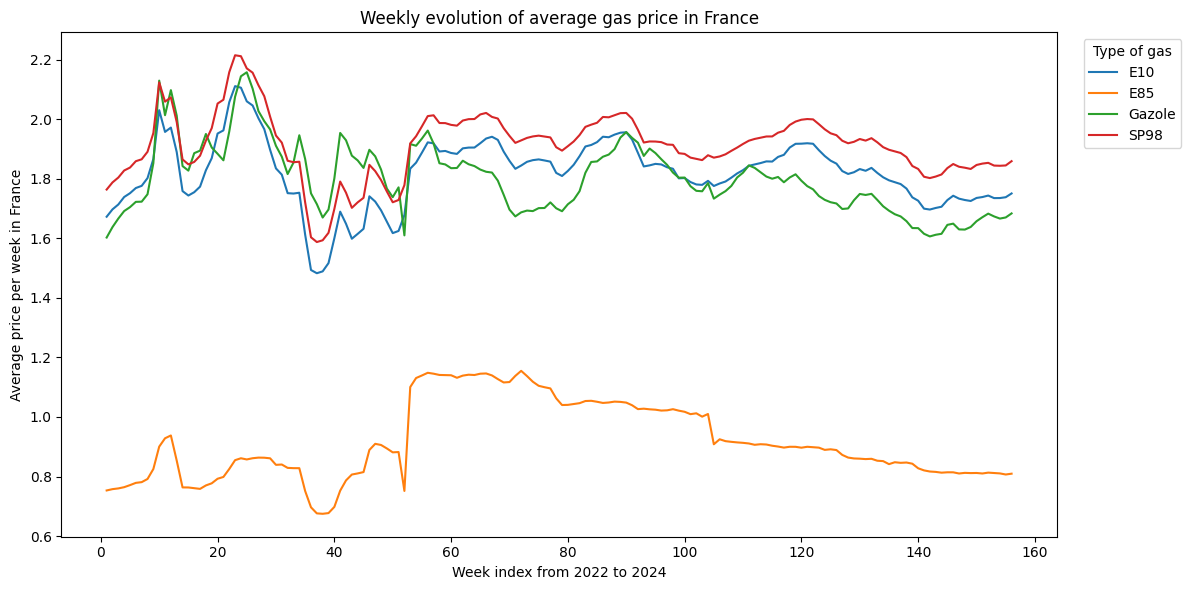

In [15]:
pd_avg_price_week = (df_avg_price_week
                        .toPandas())

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=pd_avg_price_week,
    x="week",
    y="avg_week_price",
    hue="nom_carburant",
)
plt.xlabel("Week index from 2022 to 2024")
plt.ylabel("Average price per week in France")
plt.title("Weekly evolution of average gas price in France")
plt.legend(title="Type of gas", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

+----+-------------+--------------------+
|week|nom_carburant|avg_week_price_index|
+----+-------------+--------------------+
|   1|          E10|   99.99999999999831|
|   1|          E85|   99.99999999999812|
|   1|       Gazole|   99.99999999999982|
|   1|         SP98|  100.00000000000044|
|   2|          E10|   99.99999999999876|
+----+-------------+--------------------+
only showing top 5 rows



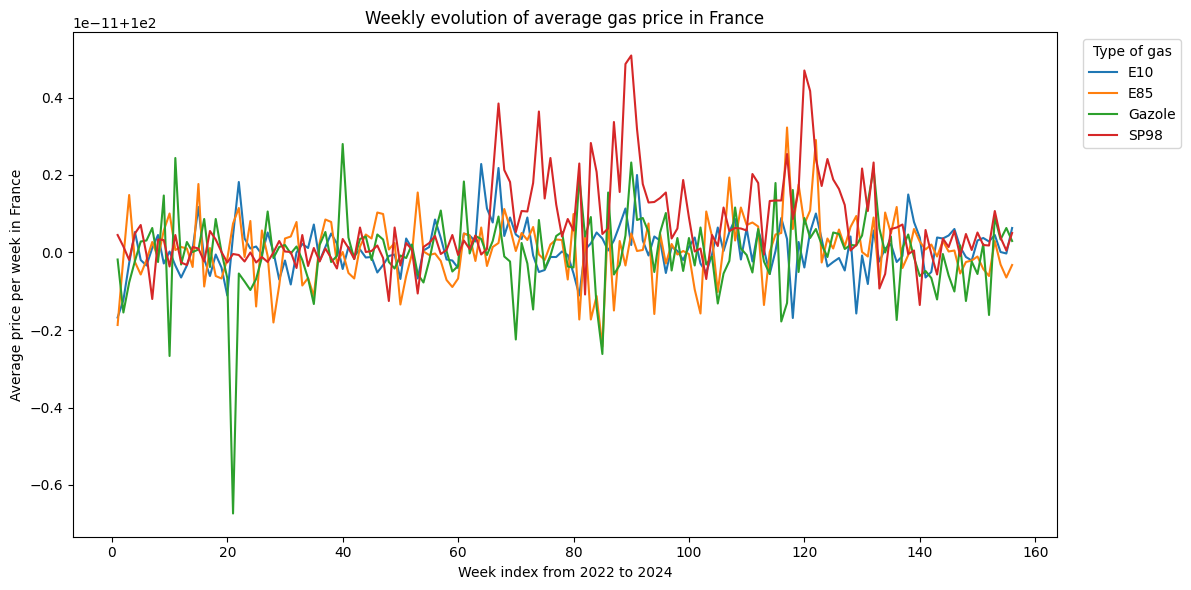

In [16]:
df_avg_price_index_week = (df_clean_join
    .groupBy("week", "nom_carburant")            
    .agg(F.avg("price_index").alias("avg_week_price_index"))
    .orderBy("week", "nom_carburant"
))
df_avg_price_index_week.show(5)

pdf_avg_price_index_week = (df_avg_price_index_week
                        .toPandas())

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=pdf_avg_price_index_week,
    x="week",
    y="avg_week_price_index",
    hue="nom_carburant",
)
plt.xlabel("Week index from 2022 to 2024")
plt.ylabel("Average price per week in France")
plt.title("Weekly evolution of average gas price in France")
plt.legend(title="Type of gas", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Model gas prices evolution


We observe that our dataset contains **more than 10,000 distinct stations**.  
Using one-hot encoding on the station identifier would therefore introduce more than 10,000 dummy variables, which would lead to the **curse of dimensionality** and strongly degrade model performance.

To avoid this issue, we choose to model gas prices at a more aggregated geographical level: the **department**.

Let:

- $cp$  be the postal code of a station.  
- The department is defined as:

$
\text{dep} = \left\lfloor \frac{cp}{1000} \right\rfloor
$




For the gas type, we choose SP98 arbitrarily. We model the daily price as a function of past prices and the department:

$
P_{t}^{(g)} = f \left(
P_{t-1}^{(g)},\;
P_{t-4}^{(g)},\;
P_{t-7}^{(g)},\;
\text{dep}
\right)
$

Where:

- $ P_{t}^{(g)}$ is the price of gas type $g$ at day

- $ P_{t-1}^{(g)}$ is the price one day before (lag-1)  

- $ P_{t-4}^{(g)}$ is the price four days before (lag-4)  

- $ P_{t-7}^{(g)}$ is the price seven days before (lag-7)  

- $ \text{dep}$ is the department identifier  




In [17]:
# creation of dep
df_clean_join = df_clean_join.withColumn(
    "dep",
    F.floor(F.col("cp") / 1000).cast("string")
)

df_clean_join.show(5)

+----------+-------------+-------+----+---+--------+---------+-------------------+------------+-----+----+-----+------------+------------------+-----------------+----+---+
|       day|nom_carburant| id_pdv|  cp|pop|latitude|longitude|               date|id_carburant| prix|year|month|week_of_year|     avg_day_price|      price_index|week|dep|
+----------+-------------+-------+----+---+--------+---------+-------------------+------------+-----+----+-----+------------+------------------+-----------------+----+---+
|2023-01-13|       Gazole|1000001|1000|  R|  46.201|    5.198|2023-01-13 09:07:40|           1|1.862|2023|    1|           2|1.9139778611632376|97.28430186064705|  54|  1|
|2023-01-05|       Gazole|1000001|1000|  R|  46.201|    5.198|2023-01-05 09:33:37|           1|1.877|2023|    1|           1|1.9289392361111177|97.30736794924493|  53|  1|
|2023-01-09|       Gazole|1000001|1000|  R|  46.201|    5.198|2023-01-09 14:51:49|           1|1.875|2023|    1|           2|1.9082695153974

In [18]:
# Filtering on super 98
# cleaning and addding the lag columns
data_model = df_clean_join.where(df_clean_join.nom_carburant == 'SP98')
window = Window.partitionBy("id_pdv").orderBy("date")

data_model = data_model.withColumn("price_1day_before", F.lag("prix", 1).over(window)) \
              .withColumn("price_4days_before", F.lag("prix", 4).over(window)) \
              .withColumn("price_7days_before", F.lag("prix", 7).over(window))

# We delete the NA lines we have 7 at most
data_model = data_model.where(F.col("price_7days_before").isNotNull())

data_model.show(10)

+----------+-------------+-------+----+---+-------------+------------------+-------------------+------------+-----+----+-----+------------+------------------+-----------------+----+---+-----------------+------------------+------------------+
|       day|nom_carburant| id_pdv|  cp|pop|     latitude|         longitude|               date|id_carburant| prix|year|month|week_of_year|     avg_day_price|      price_index|week|dep|price_1day_before|price_4days_before|price_7days_before|
+----------+-------------+-------+----+---+-------------+------------------+-------------------+------------+-----+----+-----+------------+------------------+-----------------+----+---+-----------------+------------------+------------------+
|2022-01-08|         SP98|1160005|1160|  R|46.0533506156|5.3374103671699995|2022-01-08 00:01:00|           6|1.747|2022|    1|           1|1.7834271141822935|97.95746549479846|   1|  1|            1.739|             1.738|             1.736|
|2022-01-09|         SP98|116000

We cut the last 3 month in order to make a forecast on the model with data that has not been used. But, we will not used those 3  month as a test dataset because it will be arbitrary. Instead, we will just take a proportion of the data before the last 3 months in our case 75 %.

In [19]:
data_train_test = data_model.filter(F.col("day") <= "2024-09-30")
data_forecast_val = data_model.filter(F.col("day") >= "2024-09-30")
df_train, df_test = data_train_test.randomSplit([3.0,1.0])
df_train.cache()

DataFrame[day: date, nom_carburant: string, id_pdv: int, cp: int, pop: string, latitude: double, longitude: double, date: timestamp, id_carburant: int, prix: double, year: int, month: int, week_of_year: int, avg_day_price: double, price_index: double, week: int, dep: string, price_1day_before: double, price_4days_before: double, price_7days_before: double]

Let's now do the pipeline as we have all the needed covariates. We will begin in the following by the Linear regression.

In [20]:
# encoding qualitative variable  and creation of the pipeline
dep_indexer = StringIndexer(inputCol="dep", outputCol="dep_idx")
pop_indexer = StringIndexer(inputCol="pop", outputCol="pop_idx")

ndep = OneHotEncoder(inputCol='dep_idx', outputCol='ndep') # assign 0 to the most frequent label, then 1, 2, etc. in the order for the others
npop = OneHotEncoder(inputCol='pop_idx', outputCol='npop')

vector = VectorAssembler(inputCols=['price_1day_before', 'price_4days_before', 'price_7days_before', 'ndep','npop'], outputCol='features')

pipeline = Pipeline(stages=[dep_indexer, pop_indexer, ndep, npop,vector])
pipeline.fit(df_train).transform(df_train).show(5)

+----------+-------------+--------+-----+---+------------------+------------------+-------------------+------------+-----+----+-----+------------+------------------+------------------+----+---+-----------------+------------------+------------------+-------+-------+---------------+-------------+--------------------+
|       day|nom_carburant|  id_pdv|   cp|pop|          latitude|         longitude|               date|id_carburant| prix|year|month|week_of_year|     avg_day_price|       price_index|week|dep|price_1day_before|price_4days_before|price_7days_before|dep_idx|pop_idx|           ndep|         npop|            features|
+----------+-------------+--------+-----+---+------------------+------------------+-------------------+------------+-----+----+-----+------------+------------------+------------------+----+---+-----------------+------------------+------------------+-------+-------+---------------+-------------+--------------------+
|2022-01-08|         SP98| 1160005| 1160|  R|    

As we are predicting prices, the metric that we will use in our case will be the RMSE. But we will show the forecast of the last 3 month as we said earlier.

In [25]:
# Training on the train dataset

linreg = LinearRegression(featuresCol="features",labelCol="prix")
pipeline_linreg = Pipeline(stages=pipeline.getStages() + [linreg])

# tuning the lambda
lambda_ridge = (ParamGridBuilder()
                .addGrid(linreg.regParam, [0.0, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0])
                .build()
                )

evaluator = RegressionEvaluator(labelCol="prix", predictionCol="prediction", metricName="rmse")

crossval = CrossValidator(
    estimator=pipeline_linreg,
    estimatorParamMaps=lambda_ridge,
    evaluator=evaluator,
    numFolds=5,
    parallelism=12   #you need to change corresponding to the capacity of your machine :)
)

linear_ridge_cv = crossval.fit(df_train)


26/01/13 18:51:04 WARN Instrumentation: [26633659] regParam is zero, which might cause numerical instability and overfitting.
26/01/13 18:51:20 WARN Instrumentation: [9b1d7307] regParam is zero, which might cause numerical instability and overfitting.
26/01/13 18:51:34 WARN Instrumentation: [72046f0a] regParam is zero, which might cause numerical instability and overfitting.
26/01/13 18:51:49 WARN Instrumentation: [16cf6eaa] regParam is zero, which might cause numerical instability and overfitting.
26/01/13 18:52:03 WARN Instrumentation: [36fb3d39] regParam is zero, which might cause numerical instability and overfitting.


In [26]:
# Computing RMSE and doing forecast for linear regression.

pred_test_linreg = linear_ridge_cv.transform(df_test)
pred_test_linreg.show(5)

rmse = RegressionEvaluator(
    labelCol="prix",
    predictionCol="prediction",
    metricName="rmse"
).evaluate(pred_test_linreg)

print("RMSE for the best ridge regression according to cross validation:", rmse)

+----------+-------------+--------+-----+---+--------+---------+-------------------+------------+-----+----+-----+------------+-----------------+------------------+----+---+-----------------+------------------+------------------+-------+-------+---------------+-------------+--------------------+------------------+
|       day|nom_carburant|  id_pdv|   cp|pop|latitude|longitude|               date|id_carburant| prix|year|month|week_of_year|    avg_day_price|       price_index|week|dep|price_1day_before|price_4days_before|price_7days_before|dep_idx|pop_idx|           ndep|         npop|            features|        prediction|
+----------+-------------+--------+-----+---+--------+---------+-------------------+------------+-----+----+-----+------------+-----------------+------------------+----+---+-----------------+------------------+------------------+-------+-------+---------------+-------------+--------------------+------------------+
|2022-01-05|         SP98|18100010|18100|  R|  47.21

RMSE for the best ridge regression using cross validation: 0.05291800190458771


In [27]:
best_pipeline_model = linear_ridge_cv.bestModel
best_lr = best_pipeline_model.stages[-1]

best_lambda = best_lr.getRegParam()
print("Best lambda:", best_lambda)

Best lambda: 0.0001


In [44]:
# Forecast recursively in order to see a three month forecast

data_forecast_val.show(5)
data_forecast_val.cache()

def recursive_forecast_random_station(df_3m, model_linreg):
# picking a random station and filter on that one

    station_id = (df_3m.select("id_pdv").distinct()
                  .orderBy(F.rand())
                  .limit(1).collect()[0][0])


    df_s = (df_3m.filter(F.col("id_pdv") == station_id)
                #.select("id_pdv", "day", "dep", "pop", "prix")
                .orderBy("day"))

    pdf = df_s.toPandas()
    pdf["day"] = pd.to_datetime(pdf["day"])
    pdf = pdf.sort_values("day").reset_index(drop=True)



    dep_val = pdf["dep"].iloc[0]
    pop_val = pdf["pop"].iloc[0]

    prix_true = pdf["prix"].astype(float).tolist()
    prix_eff  = prix_true.copy()   # we overwrite here
    days = pdf["day"].tolist()

    preds = []



    for i in range(len(days)):
        if i < 7:
            preds.append({"day": days[i], "prix_true": float(prix_true[i]), "prix_pred": None})
            continue

        x1 = prix_eff[i-1]
        x4 = prix_eff[i-4]
        x7 = prix_eff[i-7]

        one = spark.createDataFrame([(
            station_id,
            days[i].date(),
            dep_val,
            pop_val,
            float(x1), float(x4), float(x7),
            float(prix_true[i])
        )], schema=[
            "id_pdv", "day", "dep", "pop",
            "price_1day_before", "price_4days_before", "price_7days_before",
            "prix"
        ])

        pred_val = model_linreg.transform(one).select("prediction").collect()[0][0]

        preds.append({"day": days[i], "prix_true": float(prix_true[i]), "prix_pred": float(pred_val)})
        prix_eff[i] = float(pred_val)


    pred_df = pd.DataFrame(preds)


    return pred_df, station_id

+----------+-------------+-------+----+---+-------------+------------------+-------------------+------------+-----+----+-----+------------+------------------+-----------------+----+---+-----------------+------------------+------------------+
|       day|nom_carburant| id_pdv|  cp|pop|     latitude|         longitude|               date|id_carburant| prix|year|month|week_of_year|     avg_day_price|      price_index|week|dep|price_1day_before|price_4days_before|price_7days_before|
+----------+-------------+-------+----+---+-------------+------------------+-------------------+------------+-----+----+-----+------------+------------------+-----------------+----+---+-----------------+------------------+------------------+
|2024-09-30|         SP98|1160005|1160|  R|46.0533506156|5.3374103671699995|2024-09-30 00:01:00|           6| 1.78|2024|    9|          40|1.8089395241242519|98.40019394024452| 144|  1|             1.78|             1.787|             1.787|
|2024-10-01|         SP98|116000

26/01/13 21:16:57 WARN CacheManager: Asked to cache already cached data.


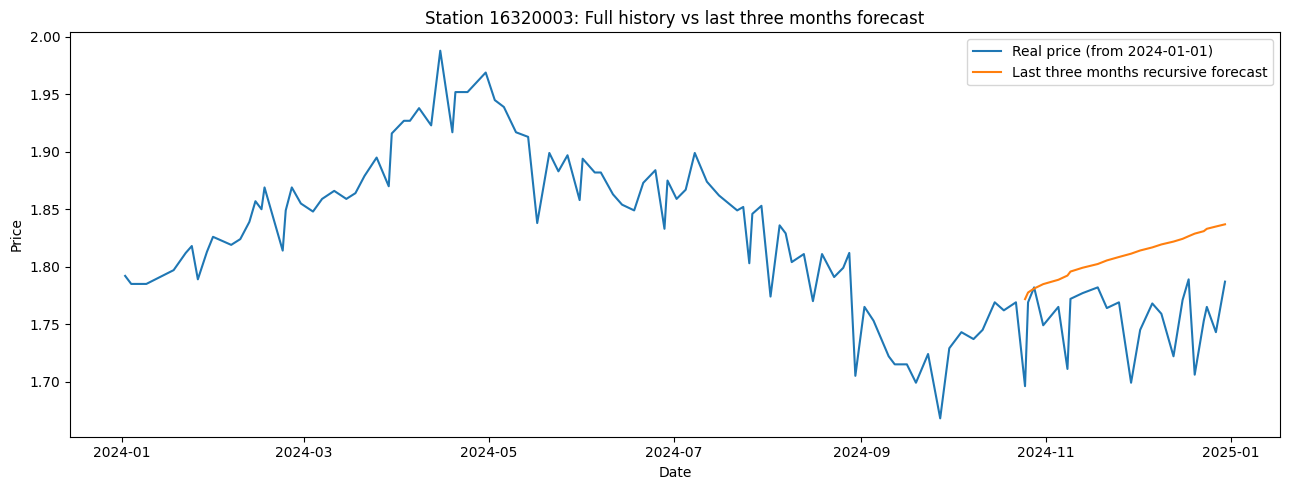

In [47]:
pred_df, station = recursive_forecast_random_station(data_forecast_val, linear_ridge_cv)

pdf_real = (data_model
    .filter(F.col("id_pdv") == station)
    .filter(F.col("day") >= F.to_date(F.lit("2024-01-01")))
    .select("day", "prix")
    .orderBy("day")
    .toPandas()
)

pdf_real["day"] = pd.to_datetime(pdf_real["day"])
pdf_real = pdf_real.sort_values("day").reset_index(drop=True)

pred_df = pred_df.copy()
pred_df["day"] = pd.to_datetime(pred_df["day"])

plt.figure(figsize=(13, 5))
plt.plot(pdf_real["day"], pdf_real["prix"].astype(float), label="Real price (from 2024-01-01)")
plt.plot(pred_df["day"], pred_df["prix_pred"], label="Last three months recursive forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.title(f"Station {station}: Full history vs last three months forecast")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Convert Spark DataFrame to Pandas
print("Converting Spark DataFrame to Pandas...")
df_pandas = df_clean_join.toPandas()

# Download GeoJSON file for French departments
print("Downloading GeoJSON for departments...")
url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements.geojson"
response = requests.get(url)
geojson_data = response.json()

# Create 'dep' column from postal code
df_pandas['dep'] = (df_pandas['cp'] // 1000).astype(str).str.zfill(2)

# Get unique gas types
gas_types = df_pandas['nom_carburant'].unique()

print(f"Gas types found: {list(gas_types)}\n")

# Create a dictionary of maps, one per gas type
maps = {}

for gas_type in gas_types:
    
    # Filter data for this gas type
    gas_data = df_pandas[df_pandas['nom_carburant'] == gas_type]
    
    # Aggregate by department (average price)
    dept_data = gas_data.groupby('dep').agg({
        'prix': 'mean'  # Adjust 'prix' based on your column name
    }).reset_index()
    
    # Rename to match GeoJSON
    dept_data = dept_data.rename(columns={'dep': 'code', 'prix': 'price_index'})
    
    print(f"Creating map for {gas_type}")
    print(f"  - Number of departments: {len(dept_data)}")
    print(f"  - Min price: {dept_data['price_index'].min():.2f}")
    print(f"  - Max price: {dept_data['price_index'].max():.2f}\n")
    
    # Create the map
    m = folium.Map(
        location=[46.5, 2.3],
        zoom_start=6,
        tiles=None,
    )
    
    # Add map background
    folium.TileLayer("CartoDB positron", name="Light Map", control=False).add_to(m)
    
    # Determine color range
    vmin = dept_data['price_index'].min()
    vmax = dept_data['price_index'].max()
    
    # Create choropleth layer
    folium.Choropleth(
        geo_data=geojson_data,
        data=dept_data,
        columns=['code', 'price_index'],
        key_on='feature.properties.code',
        fill_color='RdYlGn_r',  # Red (expensive) to Green (cheap)
        fill_opacity=0.7,
        line_opacity=0.5,
        legend_name=f'Average price - {gas_type}',
        vmin=vmin,
        vmax=vmax,
    ).add_to(m)
    
    # Add interactive tooltips
    folium.GeoJson(
        data=geojson_data,
        style_function=lambda x: {
            'fillColor': '#ffffff',
            'color': '#000000',
            'fillOpacity': 0.1,
            'weight': 0.5
        },
        tooltip=folium.GeoJsonTooltip(
            fields=['nom', 'code'], 
            aliases=['Department', 'Code']
        ),
    ).add_to(m)
    
    maps[gas_type] = m
    
    # Save the map
    filename = f'gas_price_map_{gas_type.replace(" ", "_").lower()}.html'
    m.save(filename)
    print(f" Map saved: {filename}")

print("\n" + "="*50)
print(f" {len(maps)} maps created successfully!")
print("="*50)